<a href="https://colab.research.google.com/github/irfan060606/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Data and Sampling Distributions

Notebook ini merupakan reproduksi dan *theoretical deep-dive* untuk **Chapter 2: Data and Sampling Distributions** dari *Practical Statistics for Data Scientists* (2nd Edition).

Fokus utama bab:
- random sampling dan sample bias,
- selection bias serta regression to the mean,
- sampling distribution, Central Limit Theorem, dan standard error,
- bootstrap dan confidence intervals,
- normal distribution dan QQ-plot,
- long-tailed distributions,
- Student's t-distribution,
- binomial distribution,
- chi-square distribution,
- F-distribution,
- Poisson, exponential, dan Weibull distributions.

Dataset yang digunakan mengikuti contoh buku dan diambil dari repository data resmi buku saat notebook dijalankan.

## Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kita diharapkan dapat:

1. membedakan **population**, **sample**, dan **sample statistic**;
2. memahami mengapa kualitas sampling tidak dapat digantikan hanya dengan ukuran data yang besar;
3. menjelaskan **sampling distribution**, **Central Limit Theorem**, dan **standard error**;
4. melakukan bootstrap untuk memperkirakan variabilitas suatu statistik;
5. membangun confidence interval berbasis bootstrap;
6. mengenali bentuk beberapa distribusi probabilitas yang digunakan dalam data science.

> **Catatan:** kode ditulis ulang dengan struktur dan penjelasan sendiri, tetapi konsep dan contoh utamanya mengikuti Chapter 2 buku.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 3)

# Dataset resmi dari repository pendamping buku
BASE_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

loans_income = pd.read_csv(BASE_URL + "loans_income.csv").squeeze("columns")
loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


## 1. Random Sampling and Sample Bias

**Population** adalah keseluruhan kelompok yang menjadi perhatian analisis, sedangkan **sample** adalah bagian dari population yang benar-benar diamati.

**Random sampling** digunakan agar setiap anggota population memiliki peluang yang sesuai untuk masuk ke sample. Dalam buku, random sampling tetap penting meskipun kita berada di era *big data*. Data yang sangat besar tidak otomatis bebas dari bias.

Hal yang perlu dibedakan:
- **Sample size** → berapa banyak observasi yang diambil.
- **Sample quality** → seberapa baik sample mewakili population.
- **Bias** → kesalahan sistematis karena pengukuran atau observasi tidak mewakili population secara tepat.

In [2]:
# Contoh random sample dari data income
sample_income = loans_income.sample(n=1000, random_state=42)

summary_sampling = pd.Series({
    "Population size": len(loans_income),
    "Sample size": len(sample_income),
    "Population mean": loans_income.mean(),
    "Sample mean": sample_income.mean()
})

summary_sampling

,0
Population size,50000.000
Sample size,1000.000
Population mean,68760.518
Sample mean,66536.473


### Size versus Quality

Menambah jumlah data dapat mengurangi variasi acak, tetapi tidak otomatis menghilangkan **bias**. Jika mekanisme pemilihan data sudah tidak representatif, sample yang sangat besar tetap dapat menghasilkan kesimpulan yang bias.

Dalam praktik data science, random sampling juga dapat membantu proses eksplorasi dan pemeriksaan kualitas data karena analisis pada sample yang lebih kecil sering lebih mudah dilakukan.

### Sample Mean versus Population Mean

Notasi yang umum digunakan:
- **x̄ (x-bar)** → mean dari sample.
- **μ (mu)** → mean dari population.

Perbedaannya penting karena pada banyak kasus data scientist hanya mengamati sample, kemudian menggunakan statistik sample untuk memahami population.

In [3]:
population_mean = loans_income.mean()
sample_mean = sample_income.mean()

print(f"Population mean : {population_mean:,.2f}")
print(f"Sample mean     : {sample_mean:,.2f}")

Population mean : 68,760.52
Sample mean     : 66,536.47


## 2. Selection Bias

**Selection bias** muncul ketika proses pemilihan observasi membuat sample berbeda secara sistematis dari population yang ingin dipelajari.

Salah satu masalah yang dibahas dalam bab adalah **data snooping**: mencari-cari pola dalam data sampai menemukan hasil yang terlihat menarik. Jika banyak kemungkinan pola dicoba, sebagian pola dapat muncul hanya karena kebetulan.

Konsep lain adalah **vast search effect**: semakin banyak kemungkinan yang dicari, semakin besar peluang menemukan sesuatu yang tampak menarik secara kebetulan.

Karena itu, hasil analisis perlu dipertimbangkan bersama proses bagaimana data dikumpulkan dan dipilih.

## 3. Regression to the Mean

**Regression to the mean** adalah kecenderungan pengukuran yang sangat ekstrem untuk diikuti oleh pengukuran berikutnya yang lebih dekat ke nilai rata-rata.

Ini tidak selalu berarti kondisi objek benar-benar berubah. Sebagian perubahan dapat muncul karena variasi acak pada pengukuran pertama.

Contoh sederhana: seseorang memperoleh skor yang sangat tinggi karena kombinasi kemampuan dan faktor acak. Pada pengukuran berikutnya, faktor acak tersebut mungkin tidak muncul dengan kekuatan yang sama sehingga skor lebih dekat ke rata-rata.

In [4]:
# Simulasi sederhana regression to the mean
rng = np.random.default_rng(42)

true_score = 70
first_measurement = true_score + rng.normal(0, 15, 1000)
second_measurement = true_score + rng.normal(0, 15, 1000)

# Ambil observasi dengan pengukuran pertama yang paling ekstrem
extreme = first_measurement > np.quantile(first_measurement, 0.95)

print("Rata-rata pengukuran pertama (5% tertinggi):",
      first_measurement[extreme].mean())
print("Rata-rata pengukuran kedua untuk kelompok yang sama:",
      second_measurement[extreme].mean())
print("Rata-rata populasi simulasi:", true_score)

Rata-rata pengukuran pertama (5% tertinggi): 100.06254210387344
Rata-rata pengukuran kedua untuk kelompok yang sama: 67.87586195281071
Rata-rata populasi simulasi: 70


## 4. Sampling Distribution of a Statistic

**Sampling distribution** adalah distribusi suatu statistik, misalnya mean, yang diperoleh ketika kita mengambil banyak sample dari population yang sama dan menghitung statistik tersebut berulang kali.

Ini berbeda dengan **data distribution**:
- *data distribution* → bentuk sebaran data individual;
- *sampling distribution* → bentuk sebaran statistik dari banyak sample.

### Central Limit Theorem

**Central Limit Theorem (CLT)** menjelaskan bahwa sampling distribution dari mean cenderung mendekati distribusi normal ketika ukuran sample cukup besar, meskipun data asalnya sendiri tidak normal.

Ketika ukuran sample bertambah, sampling distribution mean juga cenderung menjadi lebih sempit.

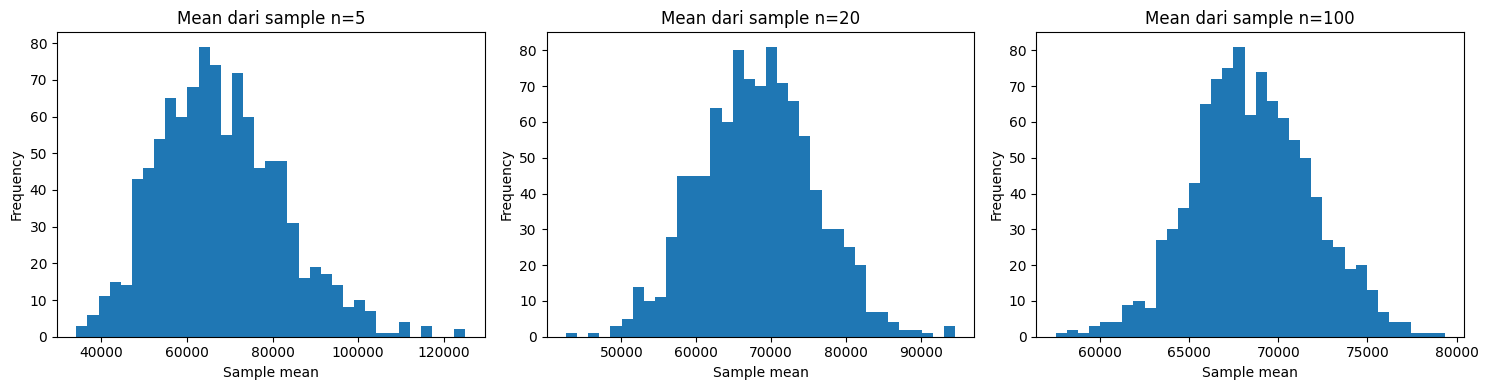

In [5]:
# Membandingkan sampling distribution mean untuk ukuran sample berbeda
def repeated_means(data, sample_size, repetitions=1000, seed=42):
    local_rng = np.random.default_rng(seed)
    values = []
    for _ in range(repetitions):
        indices = local_rng.integers(0, len(data), size=sample_size)
        values.append(data.iloc[indices].mean())
    return np.array(values)

means_5 = repeated_means(loans_income, 5)
means_20 = repeated_means(loans_income, 20)
means_100 = repeated_means(loans_income, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, values, n in zip(axes, [means_5, means_20, means_100], [5, 20, 100]):
    ax.hist(values, bins=35)
    ax.set_title(f"Mean dari sample n={n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
print("Standard error empiris:")
print(f"n=5   : {means_5.std(ddof=1):,.2f}")
print(f"n=20  : {means_20.std(ddof=1):,.2f}")
print(f"n=100 : {means_100.std(ddof=1):,.2f}")

Standard error empiris:
n=5   : 14,431.86
n=20  : 7,627.29
n=100 : 3,350.13


### Standard Error

**Standard error (SE)** mengukur variabilitas suatu *sample statistic*, bukan variabilitas individual data.

Untuk sample mean, hubungan yang sering digunakan adalah:

SE ≈ s / √n

dengan:
- **s** = standard deviation sample,
- **n** = ukuran sample.

Jadi, ketika n meningkat, standard error cenderung menurun.

In [7]:
# Perbandingan dengan pendekatan SE teoritis
s = loans_income.std(ddof=1)

for n in [5, 20, 100]:
    estimated_se = s / np.sqrt(n)
    print(f"n={n:3d} -> theoretical SE ≈ {estimated_se:,.2f}")

n=  5 -> theoretical SE ≈ 14,700.82
n= 20 -> theoretical SE ≈ 7,350.41
n=100 -> theoretical SE ≈ 3,287.20


## 5. The Bootstrap

**Bootstrap** memperkirakan sampling distribution dengan mengambil sample berulang **dengan replacement** dari data yang tersedia.

Alurnya:
1. ambil sample berukuran n dari data awal;
2. sampling dilakukan dengan replacement;
3. hitung statistik yang ingin dipelajari;
4. ulangi berkali-kali;
5. kumpulan statistik tersebut menjadi bootstrap distribution.

Bootstrap tidak menciptakan informasi baru dan tidak memperbaiki sample yang buruk. Bootstrap hanya membantu memperkirakan bagaimana statistik dapat berubah jika sampling diulang.

In [8]:
def bootstrap_statistic(data, statistic, iterations=2000, seed=42):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    n = len(data)
    estimates = np.empty(iterations)

    for i in range(iterations):
        resample = rng.choice(data, size=n, replace=True)
        estimates[i] = statistic(resample)

    return estimates

# Contoh sesuai gagasan buku: median dari sample income
income_sample = loans_income.sample(n=1000, random_state=42)
bootstrap_medians = bootstrap_statistic(income_sample, np.median)

print(f"Median sample       : {np.median(income_sample):,.0f}")
print(f"Bootstrap mean      : {bootstrap_medians.mean():,.2f}")
print(f"Bootstrap std. error: {bootstrap_medians.std(ddof=1):,.2f}")

Median sample       : 60,000
Bootstrap mean      : 60,237.18
Bootstrap std. error: 759.84


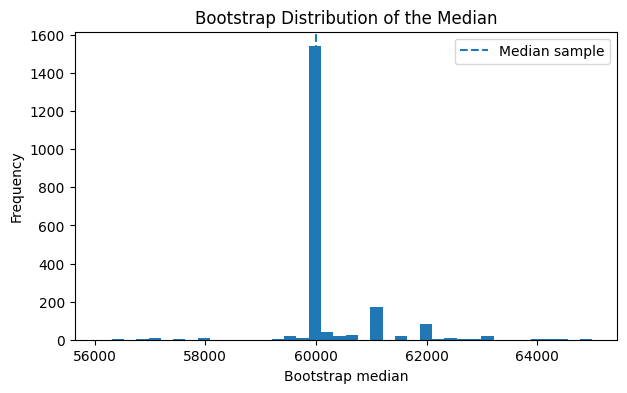

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(bootstrap_medians, bins=40)
plt.axvline(np.median(income_sample), linestyle="--",
            label="Median sample")
plt.xlabel("Bootstrap median")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Median")
plt.legend()
plt.show()

## 6. Confidence Intervals

**Confidence interval** memberikan rentang nilai untuk menggambarkan ketidakpastian suatu estimasi.

Dalam pendekatan bootstrap, confidence interval dapat diperoleh dari persentil bootstrap distribution. Misalnya, untuk **90% confidence interval**, 5% hasil paling rendah dan 5% hasil paling tinggi dikeluarkan sehingga tersisa 90% bagian tengah.

Interpretasi coverage level perlu hati-hati: confidence level mengacu pada perilaku prosedur interval ketika prosedur tersebut diulang pada banyak sample, bukan berarti setelah satu interval dihitung terdapat probabilitas 90% bahwa parameter tetap berada di dalam interval tersebut.

90% bootstrap CI: (60,000, 62,000)


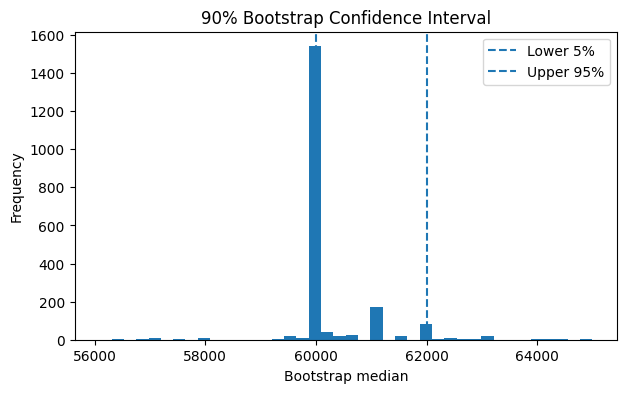

In [10]:
# 90% bootstrap confidence interval
lower, upper = np.quantile(bootstrap_medians, [0.05, 0.95])

print(f"90% bootstrap CI: ({lower:,.0f}, {upper:,.0f})")

plt.figure(figsize=(7, 4))
plt.hist(bootstrap_medians, bins=40)
plt.axvline(lower, linestyle="--", label="Lower 5%")
plt.axvline(upper, linestyle="--", label="Upper 95%")
plt.xlabel("Bootstrap median")
plt.ylabel("Frequency")
plt.title("90% Bootstrap Confidence Interval")
plt.legend()
plt.show()

## 7. Normal Distribution

Distribusi normal berbentuk lonceng dan simetris. Dalam bab ini, kegunaan utamanya bukan karena kebanyakan data mentah harus normal, tetapi karena banyak **sampling distribution** dan error yang mendekati bentuk normal.

Istilah penting:
- **standardize** → mengurangi mean lalu membagi dengan standard deviation;
- **z-score** → hasil standardisasi;
- **standard normal** → distribusi normal dengan mean 0 dan standard deviation 1;
- **QQ-plot** → alat visual untuk membandingkan distribusi data dengan distribusi referensi.

Sekitar 68% area distribusi normal berada dalam ±1 standard deviation dan sekitar 95% dalam ±2 standard deviation.

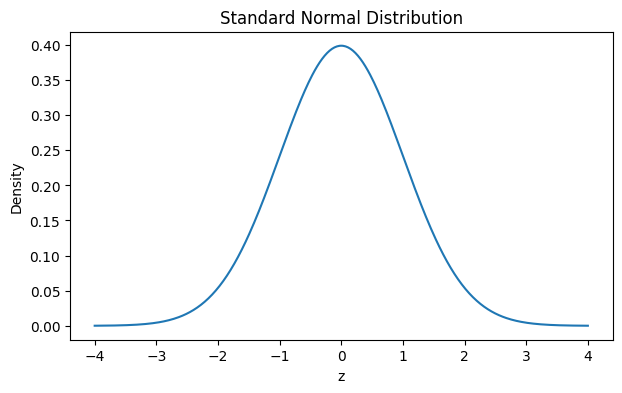

In [11]:
x = np.linspace(-4, 4, 400)
density = stats.norm.pdf(x)

plt.figure(figsize=(7, 4))
plt.plot(x, density)
plt.xlabel("z")
plt.ylabel("Density")
plt.title("Standard Normal Distribution")
plt.show()

In [12]:
# Contoh standardisasi
x_sample = loans_income.sample(1000, random_state=42)
z_scores = (x_sample - x_sample.mean()) / x_sample.std(ddof=1)

print("Mean z-score   :", z_scores.mean())
print("Std z-score    :", z_scores.std(ddof=1))

Mean z-score   : 6.750155989720952e-17
Std z-score    : 0.9999999999999915


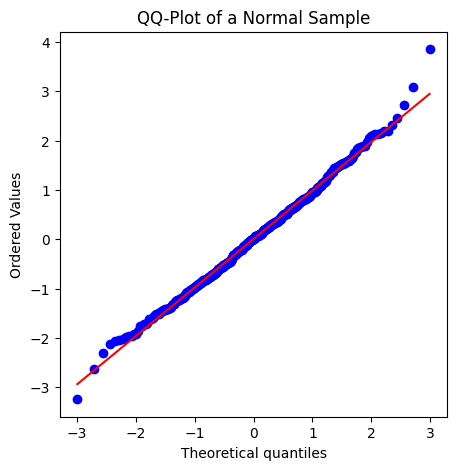

In [13]:
# QQ-plot dari data yang dibangkitkan dari distribusi normal
normal_sample = stats.norm.rvs(size=500, random_state=42)

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(normal_sample, dist="norm", plot=ax)
ax.set_title("QQ-Plot of a Normal Sample")
plt.show()

## 8. Long-Tailed Distributions

Data mentah tidak selalu mengikuti distribusi normal. **Long-tailed distribution** mempunyai ekor yang relatif panjang sehingga nilai ekstrem dapat muncul lebih sering daripada yang diperkirakan oleh model normal.

Buku menggunakan return saham Netflix (NFLX) sebagai contoh. QQ-plot membantu menunjukkan penyimpangan dari distribusi normal terutama pada bagian ekor.

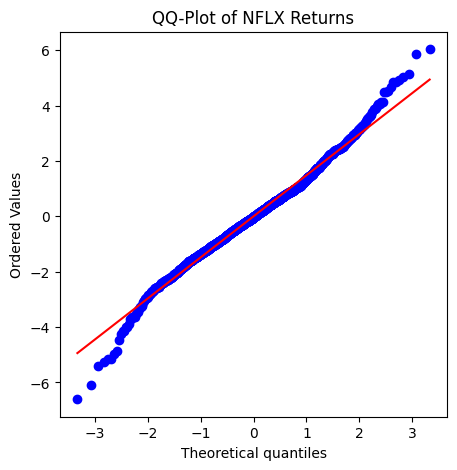

In [14]:
# Data harga/return saham dari repository buku
sp500_px = pd.read_csv(BASE_URL + "sp500_data.csv.gz", index_col=0)

nflx = sp500_px["NFLX"].dropna()
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(nflx, dist="norm", plot=ax)
ax.set_title("QQ-Plot of NFLX Returns")
plt.show()

Jika titik pada QQ-plot mengikuti garis referensi dengan baik, data lebih konsisten dengan distribusi normal. Penyimpangan kuat pada bagian ujung menunjukkan adanya ekor yang lebih berat.

Pesan penting dari buku: sebagian besar data mentah tidak normal. Mengasumsikan normalitas secara otomatis dapat menyebabkan kejadian ekstrem diremehkan.

## 9. Student's t-Distribution

**Student's t-distribution** menyerupai distribusi normal tetapi mempunyai ekor yang lebih tebal. Distribusi ini digunakan untuk menggambarkan sampling statistics dan menjadi semakin mirip dengan normal distribution ketika **degrees of freedom** bertambah.

Dalam praktik data science, t-distribution sering ditemui pada output pengujian statistik dan regresi.

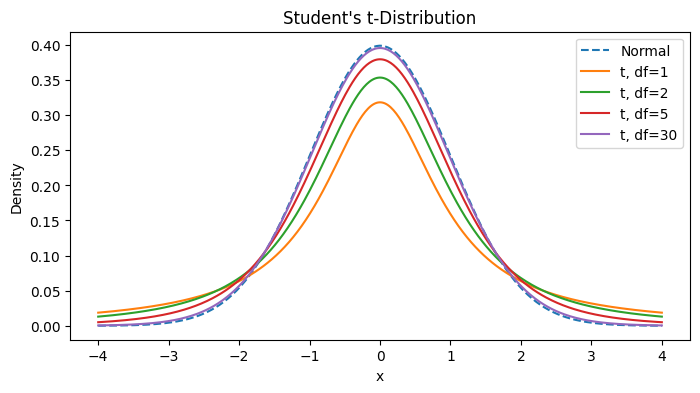

In [15]:
x = np.linspace(-4, 4, 400)

plt.figure(figsize=(8, 4))
plt.plot(x, stats.norm.pdf(x), linestyle="--", label="Normal")

for df in [1, 2, 5, 30]:
    plt.plot(x, stats.t.pdf(x, df), label=f"t, df={df}")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Student's t-Distribution")
plt.legend()
plt.show()

## 10. Binomial Distribution

**Binomial distribution** menggambarkan jumlah *successes* dari sejumlah **n trials**, ketika setiap trial mempunyai dua kemungkinan hasil dan peluang sukses **p** yang tetap.

Istilah:
- **trial** → satu percobaan;
- **success** → outcome yang menjadi perhatian;
- **binomial trial / Bernoulli trial** → percobaan dengan dua outcome;
- **n** → jumlah trial;
- **p** → peluang success.

Mean binomial = n × p.

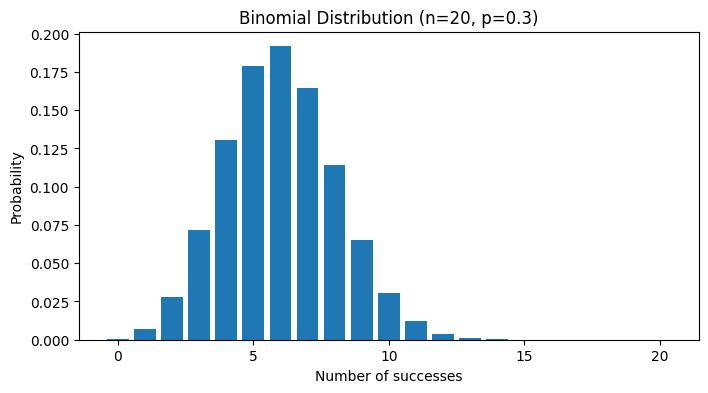

Expected number of successes: 6.0
Probability of exactly 2 successes: 0.02784587252426864
Probability of 2 or fewer successes: 0.03548313229846864


In [16]:
n = 20
p = 0.30

x = np.arange(n + 1)
probabilities = stats.binom.pmf(x, n=n, p=p)

plt.figure(figsize=(8, 4))
plt.bar(x, probabilities)
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title(f"Binomial Distribution (n={n}, p={p})")
plt.show()

print("Expected number of successes:", stats.binom.mean(n, p))
print("Probability of exactly 2 successes:", stats.binom.pmf(2, n, p))
print("Probability of 2 or fewer successes:", stats.binom.cdf(2, n, p))

## 11. Chi-Square Distribution

**Chi-square distribution** berkaitan dengan pengukuran seberapa jauh hasil yang diamati menyimpang dari apa yang diharapkan. Distribusi ini memiliki nilai non-negatif dan bentuknya berubah sesuai **degrees of freedom**.

Distribusi chi-square juga menjadi dasar untuk chi-square test yang akan dibahas lebih lanjut pada bab pengujian signifikansi.

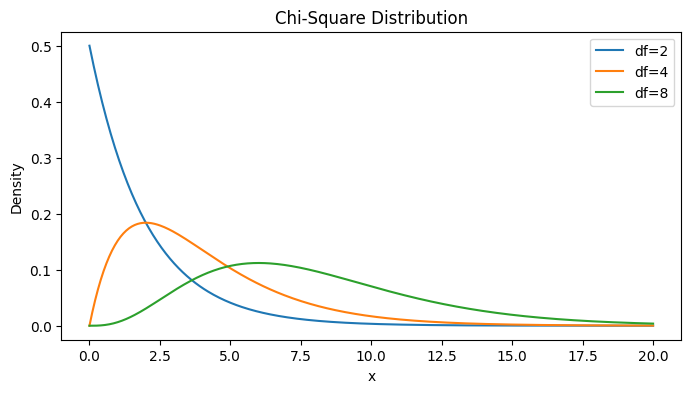

In [17]:
x = np.linspace(0, 20, 400)

plt.figure(figsize=(8, 4))
for df in [2, 4, 8]:
    plt.plot(x, stats.chi2.pdf(x, df), label=f"df={df}")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Chi-Square Distribution")
plt.legend()
plt.show()

## 12. F-Distribution

**F-distribution** digunakan dalam eksperimen dan model linear untuk membandingkan variasi. F-statistic dapat dipahami sebagai perbandingan variasi yang dijelaskan oleh faktor yang dipelajari terhadap variasi di dalam kelompok.

Distribusi F mempunyai dua degrees of freedom: satu untuk pembilang dan satu untuk penyebut.

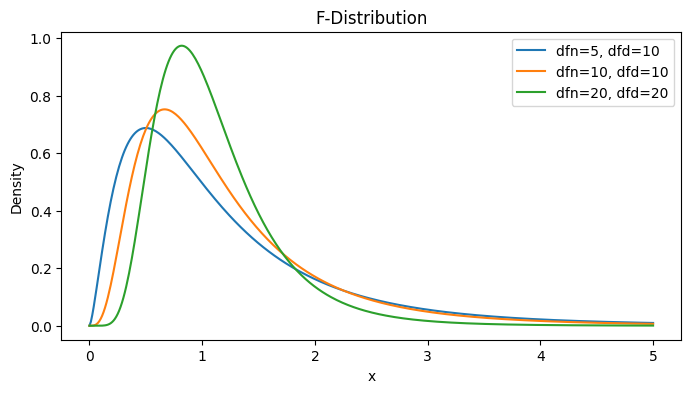

In [18]:
x = np.linspace(0, 5, 400)

plt.figure(figsize=(8, 4))
for dfn, dfd in [(5, 10), (10, 10), (20, 20)]:
    plt.plot(x, stats.f.pdf(x, dfn, dfd),
             label=f"dfn={dfn}, dfd={dfd}")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("F-Distribution")
plt.legend()
plt.show()

## 13. Poisson and Related Distributions

Bab ini juga membahas distribusi untuk kejadian yang muncul secara acak dengan suatu **rate (λ)**.

- **Poisson distribution** → jumlah kejadian dalam unit waktu atau ruang.
- **Exponential distribution** → waktu atau jarak antara satu kejadian dan kejadian berikutnya.
- **Weibull distribution** → generalisasi exponential ketika event rate dapat berubah sepanjang waktu.

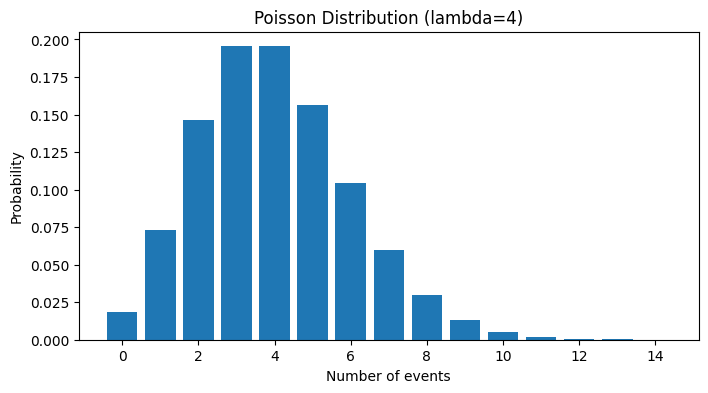

Expected number of events: 4.0


In [19]:
# Poisson: jumlah kejadian per unit waktu
lam = 4
x = np.arange(0, 15)

poisson_pmf = stats.poisson.pmf(x, mu=lam)

plt.figure(figsize=(8, 4))
plt.bar(x, poisson_pmf)
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.title(f"Poisson Distribution (lambda={lam})")
plt.show()

print("Expected number of events:", stats.poisson.mean(lam))

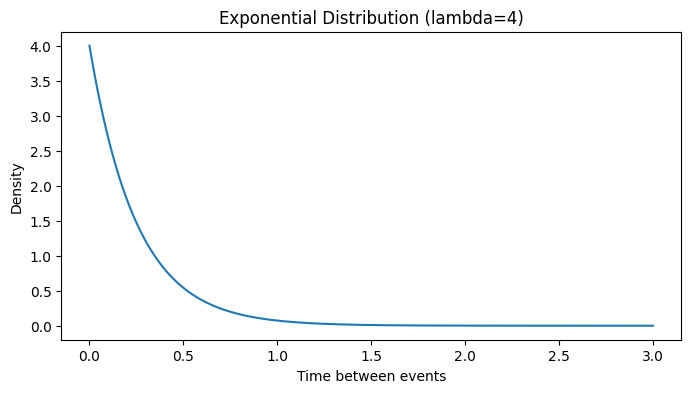

In [20]:
# Exponential: waktu antar-kejadian
x = np.linspace(0, 3, 400)
exponential_pdf = stats.expon.pdf(x, scale=1 / lam)

plt.figure(figsize=(8, 4))
plt.plot(x, exponential_pdf)
plt.xlabel("Time between events")
plt.ylabel("Density")
plt.title(f"Exponential Distribution (lambda={lam})")
plt.show()

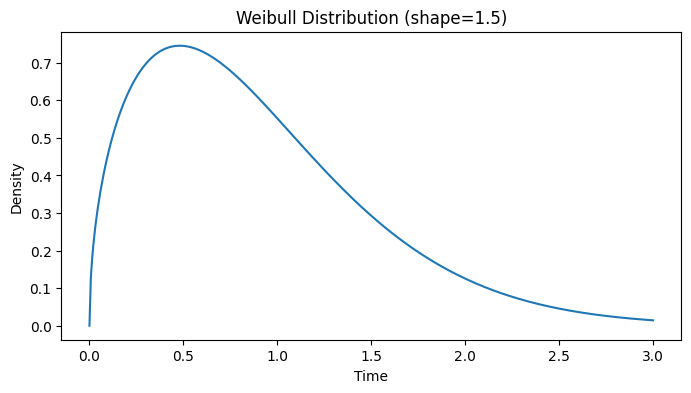

In [21]:
# Weibull: generalized exponential model
x = np.linspace(0, 3, 400)
shape = 1.5

weibull_pdf = stats.weibull_min.pdf(x, c=shape, scale=1)

plt.figure(figsize=(8, 4))
plt.plot(x, weibull_pdf)
plt.xlabel("Time")
plt.ylabel("Density")
plt.title(f"Weibull Distribution (shape={shape})")
plt.show()

## Kesimpulan Chapter 2

Chapter 2 menunjukkan bahwa statistik tidak hanya berurusan dengan angka hasil pengamatan, tetapi juga dengan **ketidakpastian yang muncul ketika kita mengambil sample dari population**.

Hal-hal yang perlu diingat:

1. **Random sampling** membantu memperoleh sample yang representatif.
2. **Bias** tidak otomatis hilang hanya karena ukuran data besar.
3. **Sampling distribution** menunjukkan bagaimana suatu statistic berubah dari sample ke sample.
4. **Central Limit Theorem** menjelaskan kecenderungan sampling distribution mean mendekati normal ketika ukuran sample bertambah.
5. **Standard error** mengukur variabilitas sample statistic.
6. **Bootstrap** menggunakan sampling with replacement untuk memperkirakan sampling distribution.
7. **Confidence interval** menyatakan rentang ketidakpastian berdasarkan suatu prosedur estimasi.
8. **Normal distribution** penting terutama untuk sampling distributions dan error, bukan karena semua data mentah harus normal.
9. **Long-tailed distributions** mengingatkan bahwa kejadian ekstrem dapat lebih sering terjadi daripada yang diprediksi model normal.
10. Distribusi **t, binomial, chi-square, F, Poisson, exponential, dan Weibull** mempunyai konteks penggunaan yang berbeda.

**Referensi utama:** Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition. O'Reilly Media.